# Netflix Dataset - Exploratory Data Analysis (EDA)

FIRST 5 ROWS
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24,

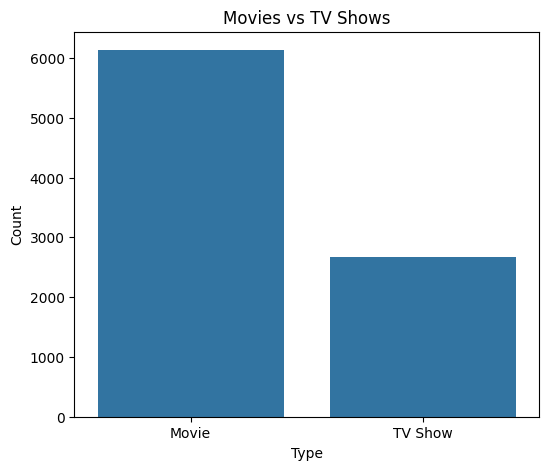

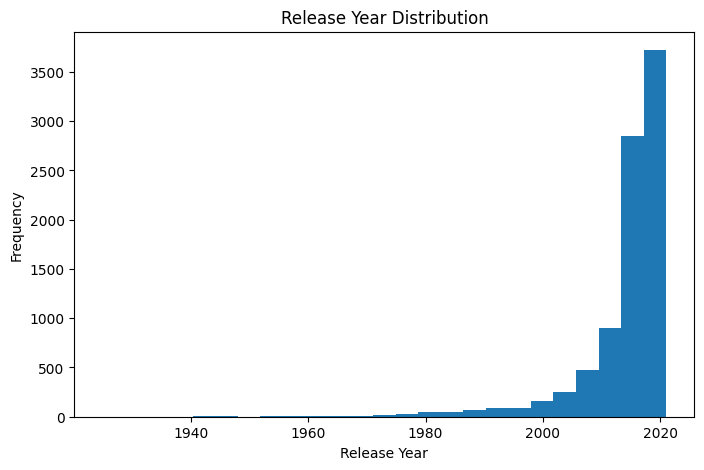

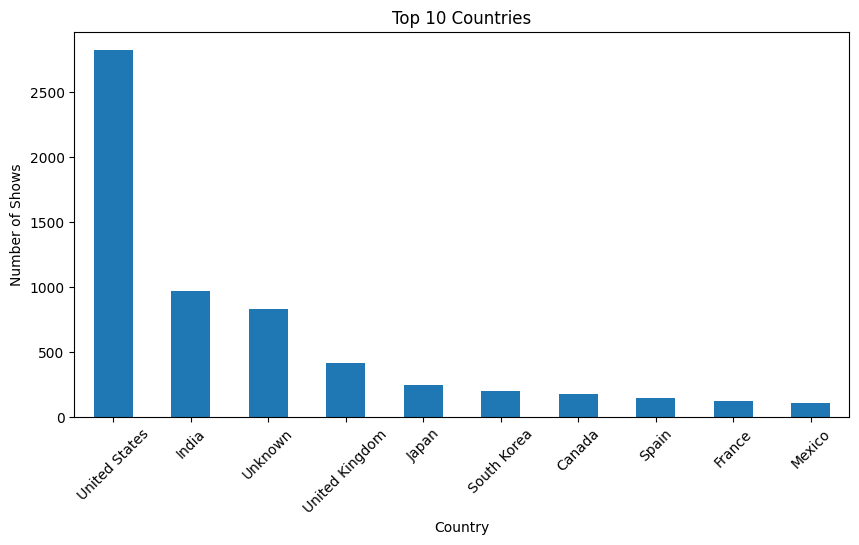

In [1]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. LOAD DATASET

df = pd.read_csv("netflix.csv")

print("=" * 50)
print("FIRST 5 ROWS")
print("=" * 50)
print(df.head())

print("\nLAST 5 ROWS")
print(df.tail())

print("\nDataset Shape:")
print(df.shape)

# 3. CLEAN THE DATASET

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Remove Duplicate Rows
df.drop_duplicates(inplace=True)

# Fill Missing Values
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])
df["duration"] = df["duration"].fillna("Unknown")

# Convert date_added to datetime
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

print("\nData Cleaning Completed")

# 4. EXPLORE THE DATASET

print("\nDataset Information")
print("-" * 30)
df.info()

print("\nData Types")
print(df.dtypes)

print("\nColumn Names")
print(df.columns)

print("\nMovies and TV Shows")
print(df["type"].value_counts())

print("\nRatings")
print(df["rating"].value_counts())

print("\nTop 10 Countries")
print(df["country"].value_counts().head(10))

print("\nTop 10 Directors")
print(df["director"].value_counts().head(10))

print("\nTop 10 Genres")
print(df["listed_in"].value_counts().head(10))

print("\nMovies Released After 2020")
print(df[df["release_year"] > 2020][["title", "release_year"]].head())

print("\nGroup By Type")
print(df.groupby("type").size())

print("\nLatest Releases")
print(df.sort_values(by="release_year", ascending=False).head())

# 5. SUMMARIZE THE DATASET

print("\nNumerical Summary")
print(df.describe())

print("\nCategorical Summary")
print(df.describe(include="object"))

years = df["release_year"].to_numpy()

print("\nNumPy Summary")

print("Mean :", np.mean(years))
print("Median :", np.median(years))
print("Minimum :", np.min(years))
print("Maximum :", np.max(years))
print("Standard Deviation :", np.std(years))
print("Variance :", np.var(years))

# 6. EDA VISUALIZATIONS

# Count Plot
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="type")
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

# Histogram
plt.figure(figsize=(8,5))
plt.hist(df["release_year"], bins=25)
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

#Bar Chart
plt.figure(figsize=(10,5))
df["country"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Shows")
plt.xticks(rotation=45)
plt.show()

DIRECTOR & DURATION ANALYSIS


DIRECTOR & DURATION ANALYSIS

Top 10 Directors by Number of Movies
director
Unknown                   188
Rajiv Chilaka              19
Raúl Campos, Jan Suter     18
Suhas Kadav                16
Marcus Raboy               15
Jay Karas                  14
Cathy Garcia-Molina        13
Martin Scorsese            12
Youssef Chahine            12
Jay Chapman                12
Name: count, dtype: int64


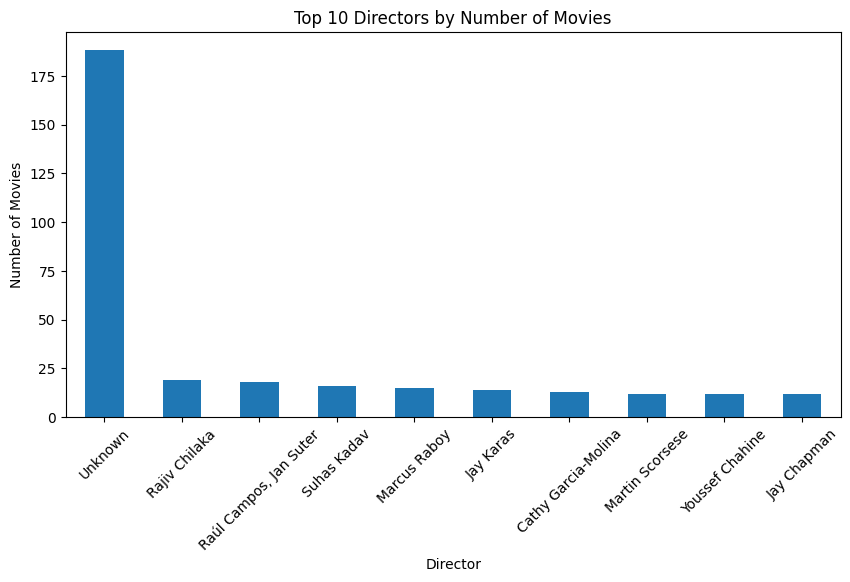


Top Directors by Average Movie Duration
director
Houssam El-Din Mustafa    253.000000
Samir Al Asfory           237.000000
Fouad El-Mohandes         233.000000
Fouad Al Shatti           204.000000
Hussein Kamal             201.500000
David Lean                200.000000
Sergio Leone              197.500000
Bassam Kurdali            196.000000
Karan Johar               195.333333
Hassan AbdulSalam         195.000000
Name: duration, dtype: float64


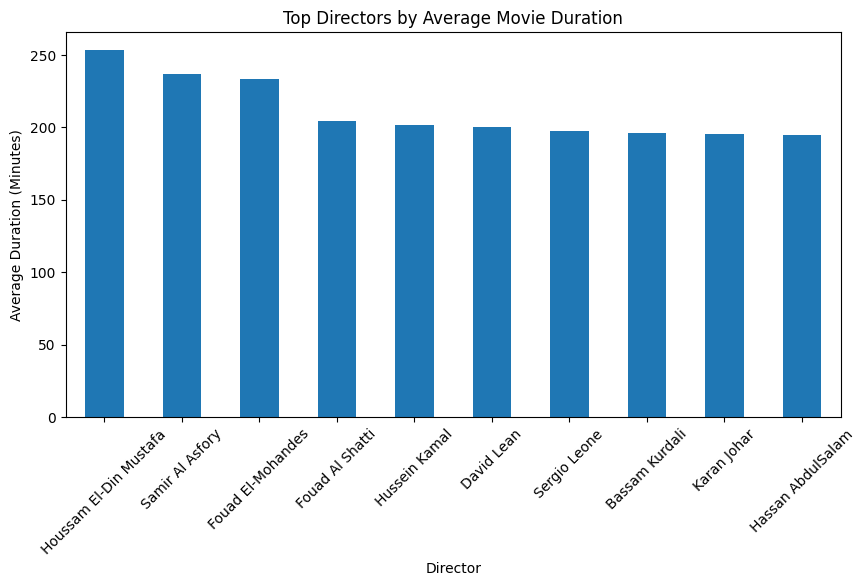


Directors with Highest Maximum Movie Duration
director
Unknown                   312.0
Houssam El-Din Mustafa    253.0
Samir Al Asfory           237.0
Fouad El-Mohandes         233.0
Hussein Kamal             230.0
Sergio Leone              229.0
Raj Kapoor                228.0
Ashutosh Gowariker        224.0
Hidenori Inoue            212.0
Karan Johar               209.0
Name: duration, dtype: float64


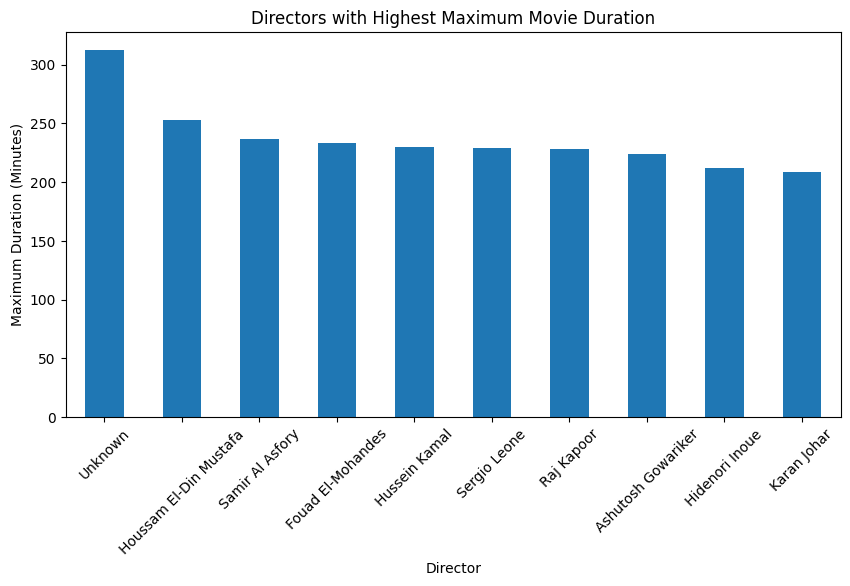


Top 10 Longest Movies
                            title                director  duration
4253   Black Mirror: Bandersnatch                 Unknown     312.0
717   Headspace: Unwind Your Mind                 Unknown     273.0
2491       The School of Mischief  Houssam El-Din Mustafa     253.0
2487               No Longer kids         Samir Al Asfory     237.0
2484           Lock Your Girls In       Fouad El-Mohandes     233.0
2488              Raya and Sakina           Hussein Kamal     230.0
166   Once Upon a Time in America            Sergio Leone     229.0
7932                       Sangam              Raj Kapoor     228.0
1019                       Lagaan      Ashutosh Gowariker     224.0
4573                 Jodhaa Akbar      Ashutosh Gowariker     214.0

Directors with Most Movies Longer Than 120 Minutes
director
David Dhawan           9
Martin Scorsese        9
Unknown                8
Youssef Chahine        7
S.S. Rajamouli         7
Hidenori Inoue         7
Steven Spielberg  

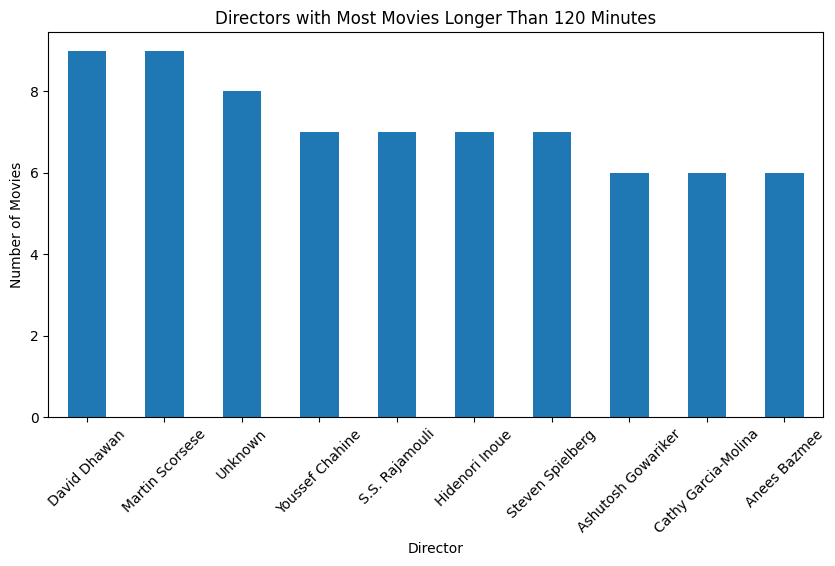

In [2]:
print("\n" + "="*60)
print("DIRECTOR & DURATION ANALYSIS")
print("="*60)

# Create a copy of movie data
movies = df[df["type"] == "Movie"].copy()

# Convert duration from text to numeric
movies["duration"] = movies["duration"].str.replace(" min", "", regex=False)
movies["duration"] = pd.to_numeric(movies["duration"], errors="coerce")

# -------------------------------------------------
# 1. Top Directors by Number of Movies
# -------------------------------------------------

print("\nTop 10 Directors by Number of Movies")
top_directors = movies["director"].value_counts().head(10)
print(top_directors)

plt.figure(figsize=(10,5))
top_directors.plot(kind="bar")
plt.title("Top 10 Directors by Number of Movies")
plt.xlabel("Director")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()


# -------------------------------------------------
# 2. Directors with Highest Average Movie Duration
# -------------------------------------------------

print("\nTop Directors by Average Movie Duration")

director_avg = (
    movies.groupby("director")["duration"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(director_avg)

plt.figure(figsize=(10,5))
director_avg.plot(kind="bar")
plt.title("Top Directors by Average Movie Duration")
plt.xlabel("Director")
plt.ylabel("Average Duration (Minutes)")
plt.xticks(rotation=45)
plt.show()


# -------------------------------------------------
# 3. Directors with Highest Maximum Movie Duration
# -------------------------------------------------

print("\nDirectors with Highest Maximum Movie Duration")

director_max = (
    movies.groupby("director")["duration"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

print(director_max)

plt.figure(figsize=(10,5))
director_max.plot(kind="bar")
plt.title("Directors with Highest Maximum Movie Duration")
plt.xlabel("Director")
plt.ylabel("Maximum Duration (Minutes)")
plt.xticks(rotation=45)
plt.show()


# -------------------------------------------------
# 4. Top 10 Longest Movies
# -------------------------------------------------

print("\nTop 10 Longest Movies")

longest_movies = movies.sort_values(
    by="duration",
    ascending=False
)[["title", "director", "duration"]].head(10)

print(longest_movies)


# -------------------------------------------------
# 5. Directors with Most Movies Longer Than 120 Minutes
# -------------------------------------------------

print("\nDirectors with Most Movies Longer Than 120 Minutes")

long_movies = movies[movies["duration"] > 120]

director_long = long_movies["director"].value_counts().head(10)

print(director_long)

plt.figure(figsize=(10,5))
director_long.plot(kind="bar")
plt.title("Directors with Most Movies Longer Than 120 Minutes")
plt.xlabel("Director")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()